In [ ]:
import pandas as pd
import numpy as np
import sklearn
import random
import time

from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from scipy.stats import randint, uniform
from joblib import parallel_backend

In [54]:
data_train = pd.read_csv('train.csv')
data_test  = pd.read_csv('test.csv')

In [55]:
data_train_copy = data_train.copy(deep=True)

In [56]:
data_cleaner = [data_train_copy, data_test]

In [57]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [58]:
data_train_copy.duplicated().sum()

np.int64(0)

In [59]:
data_test.duplicated().sum()

np.int64(0)

In [60]:
data_train_copy.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [61]:
data_test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [62]:
data_train_copy.describe(include="all")

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693,8492,8476,8494,8511,8514.000000,8490,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000,8493,8693
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2
top,9280_02,Earth,False,G/734/S,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,NaN,NaN,Anton Woody,True
freq,1,4602,5439,8,5915,NaN,8291,NaN,NaN,NaN,NaN,NaN,2,4378
mean,NaN,NaN,NaN,NaN,NaN,28.827930,NaN,224.687617,458.077203,173.729169,311.138778,304.854791,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.489021,NaN,666.717663,1611.489240,604.696458,1136.705535,1145.717189,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,47.000000,76.000000,27.000000,59.000000,46.000000,NaN,NaN


In [63]:
data_train_copy.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

In [64]:
data_train_copy.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

In [65]:
# Вещественные признаки
exp_feats=['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Категориальные признаки
cat_feats=['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

# Строковые признаки
qual_feats=['PassengerId', 'Cabin' ,'Name']

In [66]:
for dataset in data_cleaner:
    dataset['Age_group']=np.nan
    dataset.loc[dataset['Age']<=12,'Age_group']='Age_0-12'
    dataset.loc[(dataset['Age']>12) & (dataset['Age']<18),'Age_group']='Age_13-17'
    dataset.loc[(dataset['Age']>=18) & (dataset['Age']<=25),'Age_group']='Age_18-25'
    dataset.loc[(dataset['Age']>25) & (dataset['Age']<=30),'Age_group']='Age_26-30'
    dataset.loc[(dataset['Age']>30) & (dataset['Age']<=50),'Age_group']='Age_31-50'
    dataset.loc[dataset['Age']>50,'Age_group']='Age_51+'

C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\1813875581.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Age_0-12' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dataset.loc[dataset['Age']<=12,'Age_group']='Age_0-12'
C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\1813875581.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Age_0-12' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dataset.loc[dataset['Age']<=12,'Age_group']='Age_0-12'


Text(0.5, 1.0, 'Распределение возрастов')

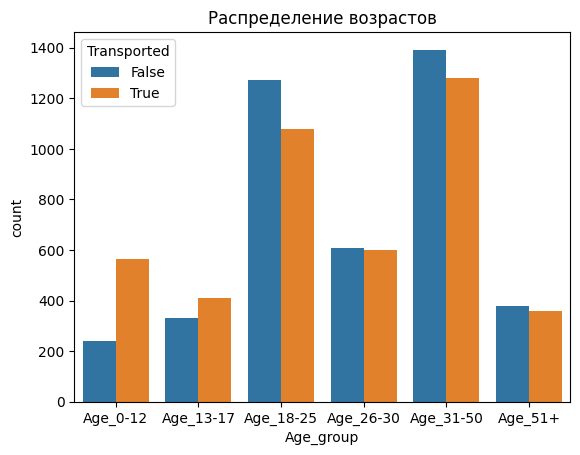

In [67]:
g=sns.countplot(data=data_train_copy, x='Age_group', hue='Transported', order=['Age_0-12','Age_13-17','Age_18-25','Age_26-30','Age_31-50','Age_51+'])
plt.title('Распределение возрастов')

In [68]:
for dataset in data_cleaner:
    dataset["Expenditure"] = dataset[exp_feats].sum(axis=1)
    dataset["No_spending"] = (dataset["Expenditure"] == 0).astype(int)

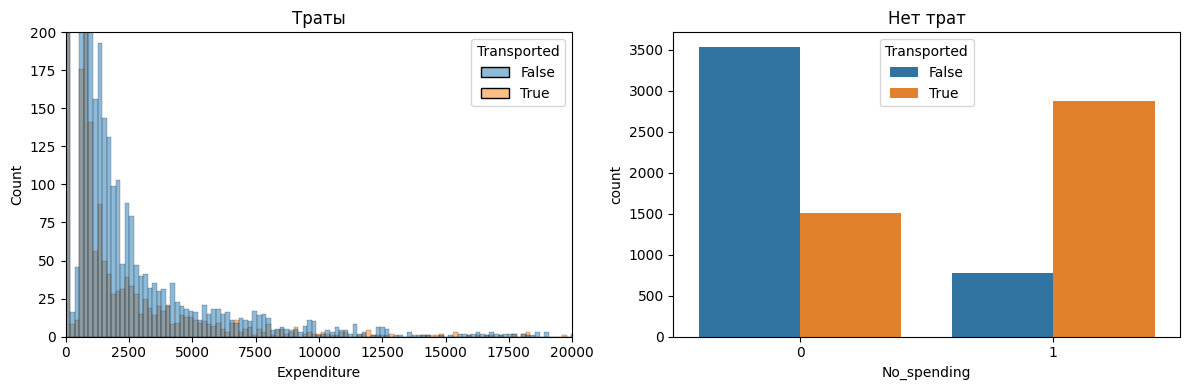

In [69]:
fig=plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data=data_train_copy, x='Expenditure', hue='Transported', bins=200)
plt.title('Траты')
plt.ylim([0,200])
plt.xlim([0,20000])

plt.subplot(1,2,2)
sns.countplot(data=data_train_copy, x='No_spending', hue='Transported')
plt.title('Нет трат')
fig.tight_layout()

# На вскиду те, кто не тратил на доп расходы, выживали чаще, но скорее всего зависимость будет больше от VIP

In [70]:
for dataset in data_cleaner:
    dataset["Group"] = dataset["PassengerId"].apply(lambda x: x.split("_")[0]).astype(int)
    group_count = dataset['Group'].value_counts()
    dataset['Group_size'] = dataset['Group'].map(lambda x: group_count[x])

In [71]:
data_cleaner[0]["Group"].value_counts()

Group
8168    8
5756    8
4005    8
9081    8
5133    8
       ..
1403    1
9276    1
9278    1
9279    1
8097    1
Name: count, Length: 6217, dtype: int64

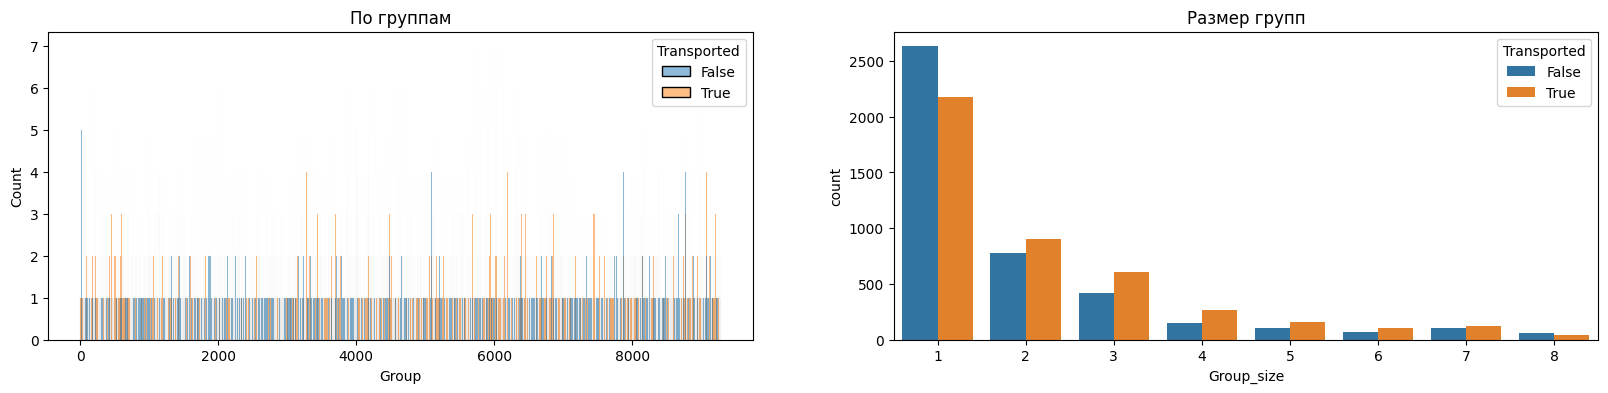

In [72]:
plt.figure(figsize=(20,4))
plt.subplot(1,2,1)
sns.histplot(data=data_train_copy, x='Group', hue='Transported', binwidth=1)
plt.title('По группам')

plt.subplot(1,2,2)
sns.countplot(data=data_train_copy, x='Group_size', hue='Transported')
plt.title('Размер групп')
fig.tight_layout()

(0.0, 3000.0)

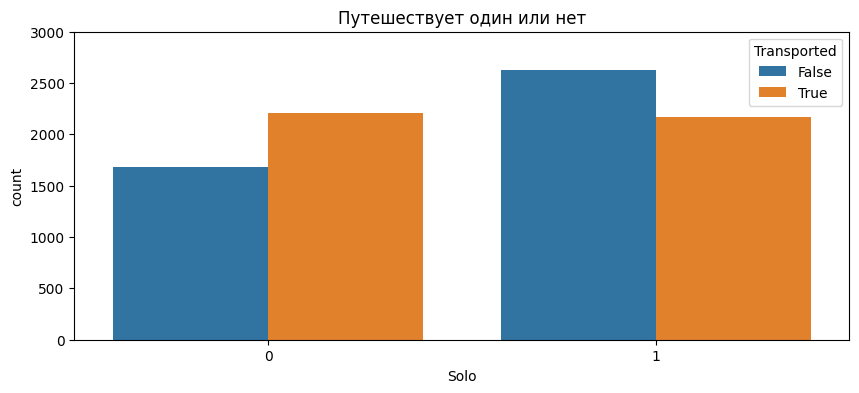

In [73]:
for dataset in data_cleaner: 
    dataset['Solo']=(dataset['Group_size']==1).astype(int)

plt.figure(figsize=(10,4))
sns.countplot(data=data_train_copy, x='Solo', hue='Transported')
plt.title('Путешествует один или нет')
plt.ylim([0,3000])

In [74]:
for dataset in data_cleaner: 

    dataset['Cabin'].fillna('NA/9999/NA', inplace=True)
    dataset['Cabin_deck'] = dataset['Cabin'].apply(lambda x: x.split('/')[0])
    dataset['Cabin_number'] = dataset['Cabin'].apply(lambda x: x.split('/')[1]).astype(int)
    dataset['Cabin_side'] = dataset['Cabin'].apply(lambda x: x.split('/')[2])
    dataset.loc[dataset['Cabin_deck']=='NA', 'Cabin_deck']=np.nan
    dataset.loc[dataset['Cabin_number']==9999, 'Cabin_number']=np.nan
    dataset.loc[dataset['Cabin_side']=='NA', 'Cabin_side']=np.nan
    dataset.drop('Cabin', axis=1, inplace=True)

C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\3820831883.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Cabin'].fillna('NA/9999/NA', inplace=True)
C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\3820831883.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

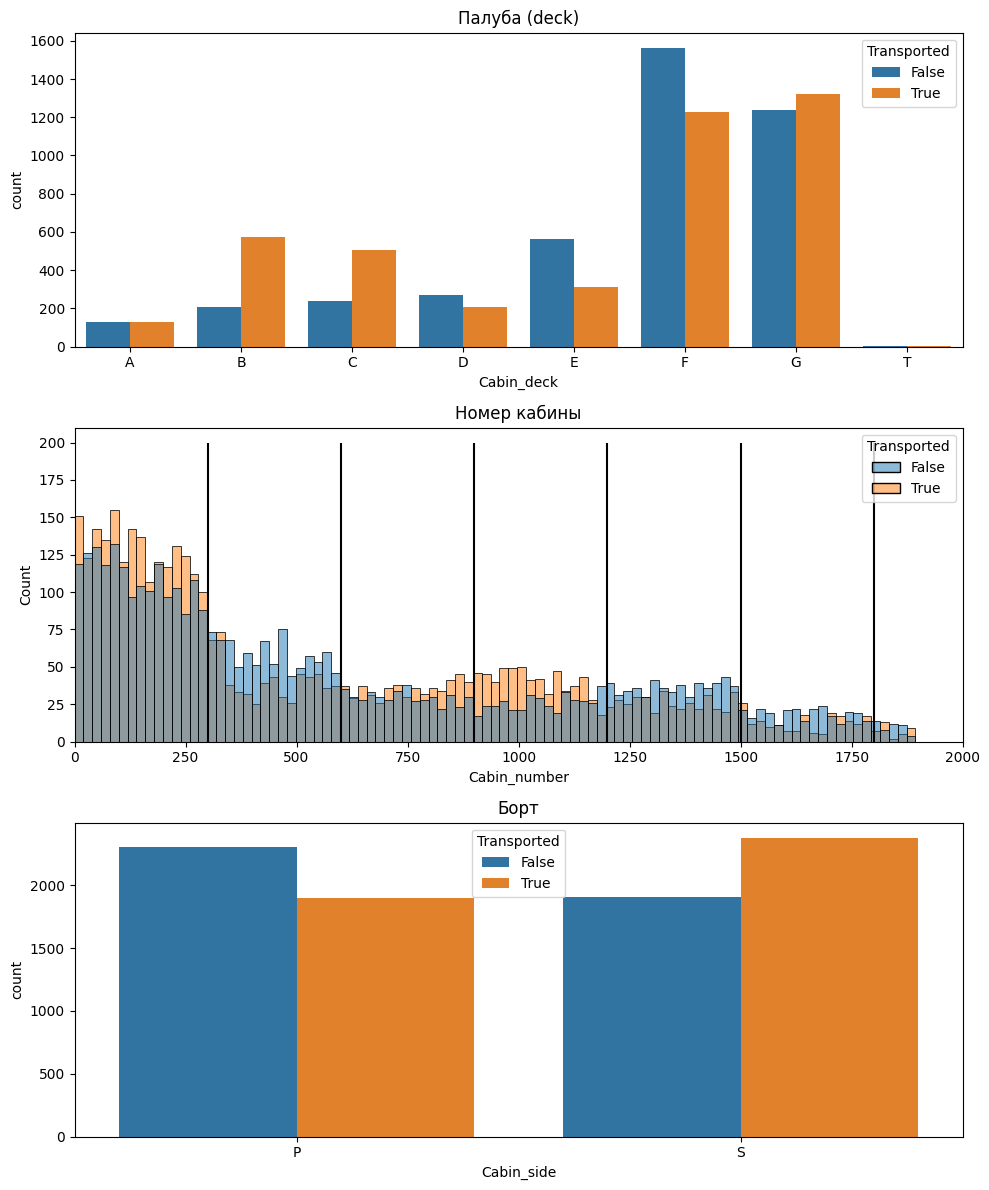

In [75]:
fig=plt.figure(figsize=(10,12))
plt.subplot(3,1,1)
sns.countplot(data=data_train_copy, x='Cabin_deck', hue='Transported', order=['A','B','C','D','E','F','G','T'])
plt.title('Палуба (deck)')

plt.subplot(3,1,2)
sns.histplot(data=data_train_copy, x='Cabin_number', hue='Transported',binwidth=20)
plt.vlines(300, ymin=0, ymax=200, color='black')
plt.vlines(600, ymin=0, ymax=200, color='black')
plt.vlines(900, ymin=0, ymax=200, color='black')
plt.vlines(1200, ymin=0, ymax=200, color='black')
plt.vlines(1500, ymin=0, ymax=200, color='black')
plt.vlines(1800, ymin=0, ymax=200, color='black')
plt.title('Номер кабины')
plt.xlim([0,2000])

plt.subplot(3,1,3)
sns.countplot(data=data_train_copy, x='Cabin_side', hue='Transported')
plt.title('Борт')
fig.tight_layout()

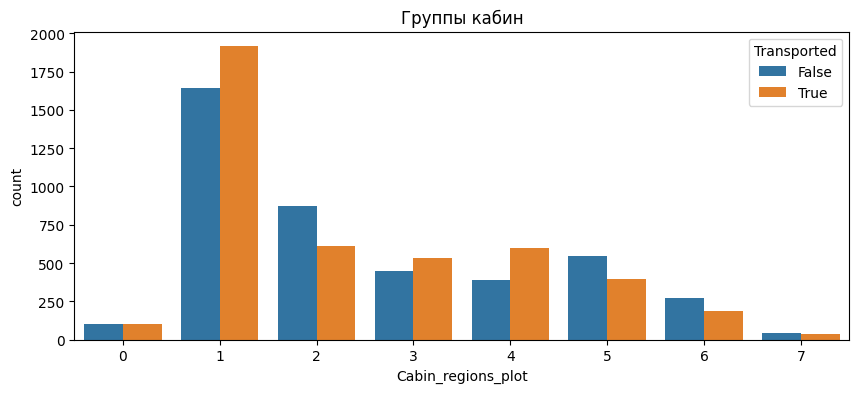

In [76]:
for dataset in data_cleaner:
    dataset['Cabin_region1']=(dataset['Cabin_number']<300).astype(int)   # one-hot encoding
    dataset['Cabin_region2']=((dataset['Cabin_number']>=300) & (dataset['Cabin_number']<600)).astype(int)
    dataset['Cabin_region3']=((dataset['Cabin_number']>=600) & (dataset['Cabin_number']<900)).astype(int)
    dataset['Cabin_region4']=((dataset['Cabin_number']>=900) & (dataset['Cabin_number']<1200)).astype(int)
    dataset['Cabin_region5']=((dataset['Cabin_number']>=1200) & (dataset['Cabin_number']<1500)).astype(int)
    dataset['Cabin_region6']=((dataset['Cabin_number']>=1500) & (dataset['Cabin_number']<1800)).astype(int)
    dataset['Cabin_region7']=(dataset['Cabin_number']>=1800).astype(int)

plt.figure(figsize=(10,4))
data_train_copy['Cabin_regions_plot']= (data_train_copy['Cabin_region1']
     +2*data_train_copy['Cabin_region2']
     +3*data_train_copy['Cabin_region3']
     +4*data_train_copy['Cabin_region4']
     +5*data_train_copy['Cabin_region5']
     +6*data_train_copy['Cabin_region6']
     +7*data_train_copy['Cabin_region7']).astype(int)
sns.countplot(data=data_train_copy, x='Cabin_regions_plot', hue='Transported')
plt.title('Группы кабин')
data_train_copy.drop('Cabin_regions_plot', axis=1, inplace=True)

In [77]:
for dataset in data_cleaner:
    dataset['Name'].fillna('Неизвестен БезНазвания', inplace=True)
    dataset['Surname']=dataset['Name'].str.split().str[-1]
    family_counts = dataset['Surname'].value_counts()
    # Я не уверен, что это хорошая идея. Мы по факту просто однофамильцев смотрим
    dataset['Family_size']=dataset['Surname'].map(lambda x: family_counts[x])
    dataset.loc[dataset['Surname']=='БезНазвания','Surname']=np.nan
    dataset.loc[dataset['Family_size']>100,'Family_size']=np.nan
    dataset.drop('Name', axis=1, inplace=True)

C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\2060457022.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Name'].fillna('Неизвестен БезНазвания', inplace=True)
C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\2060457022.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

Text(0.5, 1.0, 'Family size')

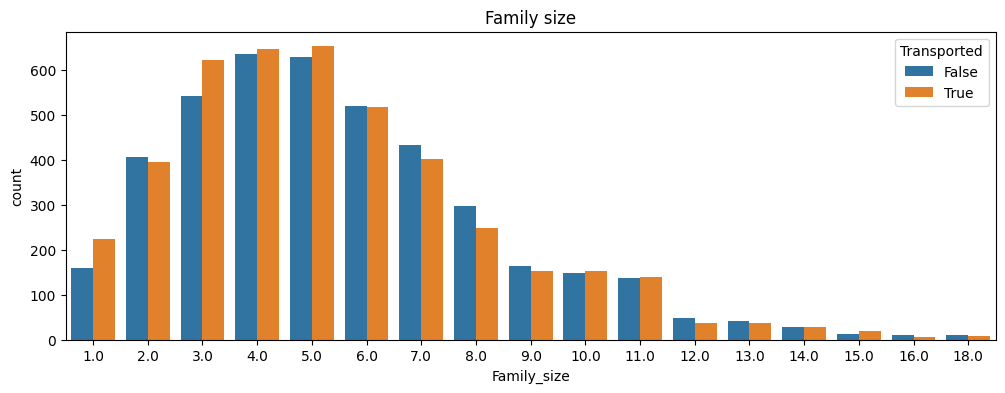

In [78]:
plt.figure(figsize=(12,4))
sns.countplot(data=data_train_copy, x='Family_size', hue='Transported')
plt.title('Family size')

In [79]:
for dataset in data_cleaner:
    na_cols=dataset.columns[dataset.isna().any()].tolist()
    mv=pd.DataFrame(dataset[na_cols].isna().sum(), columns=['Number_missing'])
    mv['Percentage_missing']=np.round(100*mv['Number_missing']/len(dataset),2)
    print(mv, '\n')

              Number_missing  Percentage_missing
HomePlanet               201                2.31
CryoSleep                217                2.50
Destination              182                2.09
Age                      179                2.06
VIP                      203                2.34
RoomService              181                2.08
FoodCourt                183                2.11
ShoppingMall             208                2.39
Spa                      183                2.11
VRDeck                   188                2.16
Age_group                179                2.06
Cabin_deck               199                2.29
Cabin_number             199                2.29
Cabin_side               199                2.29
Surname                  200                2.30
Family_size              200                2.30 

              Number_missing  Percentage_missing
HomePlanet                87                2.03
CryoSleep                 93                2.17
Destination       

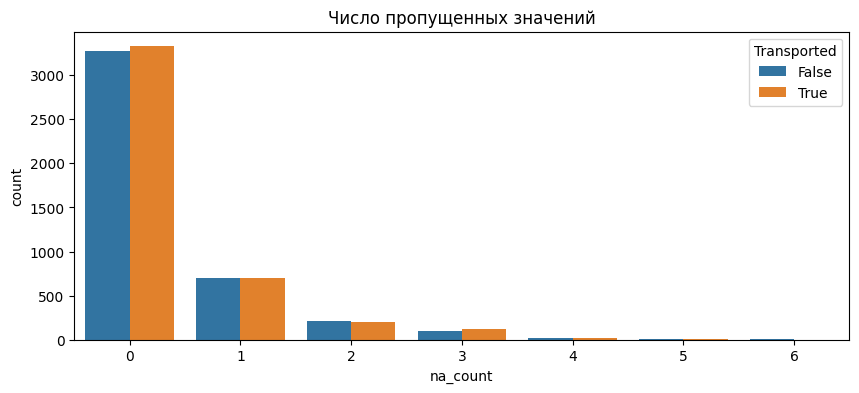

In [80]:
# Цифры снизу означают сколько значений (в скольки колонках) в строке пропущено значение
data_train_copy['na_count']=data_train_copy.isna().sum(axis=1)
plt.figure(figsize=(10,4))
sns.countplot(data=data_train_copy, x='na_count', hue='Transported')
plt.title('Число пропущенных значений')
data_train_copy.drop('na_count', axis=1, inplace=True)

In [81]:
data_cleaner[0].groupby(['Group','HomePlanet'])['HomePlanet'].size().unstack()

HomePlanet,Earth,Europa,Mars
Group,,,
1,NaN,1.0,NaN
2,1.0,NaN,NaN
3,NaN,2.0,NaN
4,1.0,NaN,NaN
5,1.0,NaN,NaN
...,...,...,...
9275,NaN,3.0,NaN
9276,NaN,1.0,NaN
9278,1.0,NaN,NaN


In [82]:
for dataset in data_cleaner:

    # Предполагаем, что человек будет с той планеты, с которой самое большое колво из его группы

    GHP_gb=dataset.groupby(['Group','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
    
    HP_bef=dataset['HomePlanet'].isna().sum()

    GHP_index=dataset[dataset['HomePlanet'].isna()][(dataset[dataset['HomePlanet'].isna()]['Group']).isin(GHP_gb.index)].index

    # idxmax ищет наибольшее значение в строке
    dataset.loc[GHP_index,'HomePlanet']=dataset.iloc[GHP_index,:]['Group'].map(lambda x: GHP_gb.idxmax(axis=1)[x])

    print('#HomePlanet missing values before:',HP_bef)
    print('#HomePlanet missing values after:',dataset['HomePlanet'].isna().sum())


#HomePlanet missing values before: 201
#HomePlanet missing values after: 111
#HomePlanet missing values before: 87
#HomePlanet missing values after: 46


<Axes: xlabel='HomePlanet', ylabel='Cabin_deck'>

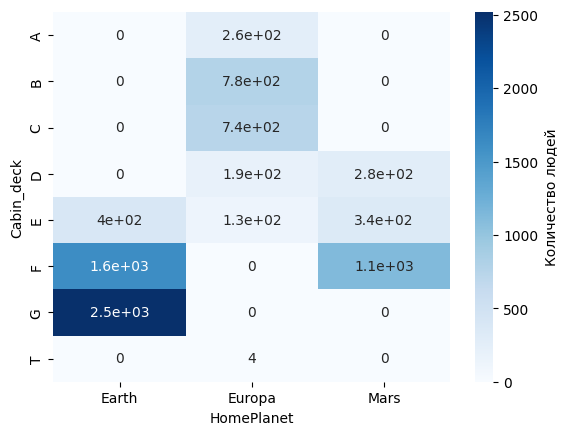

In [83]:
# Строим таблицу, в которой показано количество людей на палубе в разрезе родной планеты

pivot_table = data_cleaner[0][["HomePlanet", "Cabin_deck"]].pivot_table(index='Cabin_deck', columns='HomePlanet', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='Blues', cbar_kws={'label': 'Количество людей'})

In [84]:
'''
Пассажиры на палубах A, B, C, T из Европы
Пассажиры на палубе G из Земли
Пассажиры на палубах D,E,F пока не понятно. Могут быть с разных
'''

for dataset in data_cleaner:
    
    HP_bef=dataset['HomePlanet'].isna().sum()

    dataset.loc[(dataset['HomePlanet'].isna()) & (dataset['Cabin_deck'].isin(['A', 'B', 'C', 'T'])), 'HomePlanet']='Europa'

    dataset.loc[(dataset['HomePlanet'].isna()) & (dataset['Cabin_deck']=='G'), 'HomePlanet']='Earth'

    print('Пропущенных до:',HP_bef)
    print('Пропущенных после:',dataset['HomePlanet'].isna().sum())

Пропущенных до: 111
Пропущенных после: 63
Пропущенных до: 46
Пропущенных после: 31


In [85]:
for data in data_cleaner:

    # Если у людей одинаковая фамилия, то будем считать, что они с одной планеты
    SHP_gb=data.groupby(['Surname','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
    HP_bef=data['HomePlanet'].isna().sum()

    SHP_index=data[data['HomePlanet'].isna()][(data[data['HomePlanet'].isna()]['Surname']).isin(SHP_gb.index)].index

    data.loc[SHP_index,'HomePlanet']=data.iloc[SHP_index,:]['Surname'].map(lambda x: SHP_gb.idxmax(axis=1)[x])

    print('Пропущенных до:',HP_bef)
    print('Пропущенных после:',data['HomePlanet'].isna().sum())

Пропущенных до: 63
Пропущенных после: 8
Пропущенных до: 31
Пропущенных после: 11


In [86]:
for data in data_cleaner:
    
    HP_bef=data['HomePlanet'].isna().sum()

    # Если не на D то земля иначе Марс
    data.loc[(data['HomePlanet'].isna()) & ~(data['Cabin_deck']=='D'), 'HomePlanet']='Earth'
    data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck']=='D'), 'HomePlanet']='Mars'

    print('Пропущенных до:',HP_bef)
    print('Пропущенных после:',data['HomePlanet'].isna().sum())

Пропущенных до: 8
Пропущенных после: 0
Пропущенных до: 11
Пропущенных после: 0


In [87]:
for data in data_cleaner:

    D_bef=dataset['Destination'].isna().sum()
    
    D_gb=dataset.groupby(['Group','Destination'])['Destination'].size().unstack().fillna(0)

    # Те, у кого не заполнено направление, но при этом в его группе есть люди, у которых указано направление
    D_index=dataset[dataset['Destination'].isna()][(dataset[dataset['Destination'].isna()]['Group']).isin(D_gb.index)].index

    # idxmax ищет наибольшее значение в строке
    dataset.loc[D_index,'Destination']=dataset.iloc[D_index,:]['Group'].map(lambda x: D_gb.idxmax(axis=1)[x])

    print('Пропущенных до:',D_bef)
    print('Пропущенных после:',dataset['Destination'].isna().sum())


Пропущенных до: 92
Пропущенных после: 51
Пропущенных до: 51
Пропущенных после: 51


In [88]:
data["Destination"].value_counts()

Destination
TRAPPIST-1e      2985
55 Cancri e       850
PSO J318.5-22     391
Name: count, dtype: int64

In [89]:
for data in data_cleaner:

    D_bef=data['Destination'].isna().sum()

    # Заполняем модой
    data.loc[(data['Destination'].isna()), 'Destination']='TRAPPIST-1e'

    print('Пропущенных до:',D_bef)
    print('Пропущенных после:',data['Destination'].isna().sum())

Пропущенных до: 182
Пропущенных после: 0
Пропущенных до: 51
Пропущенных после: 0


In [90]:
dataset = data_cleaner[0]
# Количество групп всего
num_groups = dataset["Group"].nunique()

count_surnames_in_groups = dataset[["Surname", "Group"]].groupby(["Group"]).nunique().reset_index()
# Количество групп, в которых больше одной фамилии
num_different_groups = len(count_surnames_in_groups[count_surnames_in_groups["Surname"] > 1])
num_groups - num_different_groups
num_groups

6217

In [91]:
for data in data_cleaner:

    GSN_gb=data[data['Group_size']>1].groupby(['Group','Surname'])['Surname'].size().unstack().fillna(0)

    # Всего 249/6217 групп содержит больше одной фамилии, поэтому попробуем заполнить фамилию по самой частой фамилии в группе
    SN_bef=data['Surname'].isna().sum()

    GSN_index=data[data['Surname'].isna()][(data[data['Surname'].isna()]['Group']).isin(GSN_gb.index)].index

    data.loc[GSN_index,'Surname']=data.iloc[GSN_index,:]['Group'].map(lambda x: GSN_gb.idxmax(axis=1)[x])

    print('Пропущенных до:',SN_bef)
    print('Пропущенных после:',data['Surname'].isna().sum())

    data['Surname'].fillna('Unknown', inplace=True)

    data['Family_size']=data['Surname'].map(lambda x: data['Surname'].value_counts()[x])

    data.loc[data['Surname']=='Unknown','Surname']=np.nan

    data.loc[data['Family_size']>100,'Family_size']=0

Пропущенных до: 200
Пропущенных после: 104


C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\1566029628.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Surname'].fillna('Unknown', inplace=True)


Пропущенных до: 94
Пропущенных после: 51


C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\1566029628.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Surname'].fillna('Unknown', inplace=True)


In [92]:
for data in data_cleaner:
    
    GCD_gb=data[data['Group_size']>1].groupby(['Group','Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)
    GCN_gb=data[data['Group_size']>1].groupby(['Group','Cabin_number'])['Cabin_number'].size().unstack().fillna(0)
    GCS_gb=data[data['Group_size']>1].groupby(['Group','Cabin_side'])['Cabin_side'].size().unstack().fillna(0)

    # Все кто в группе находятся будут на том же борту
    CS_bef=data['Cabin_side'].isna().sum()

    GCS_index=data[data['Cabin_side'].isna()][(data[data['Cabin_side'].isna()]['Group']).isin(GCS_gb.index)].index

    data.loc[GCS_index,'Cabin_side']=data.iloc[GCS_index,:]['Group'].map(lambda x: GCS_gb.idxmax(axis=1)[x])

    print('Пропущенных до:',CS_bef)
    print('Пропущенных после:',data['Cabin_side'].isna().sum())

Пропущенных до: 199
Пропущенных после: 99
Пропущенных до: 100
Пропущенных после: 63


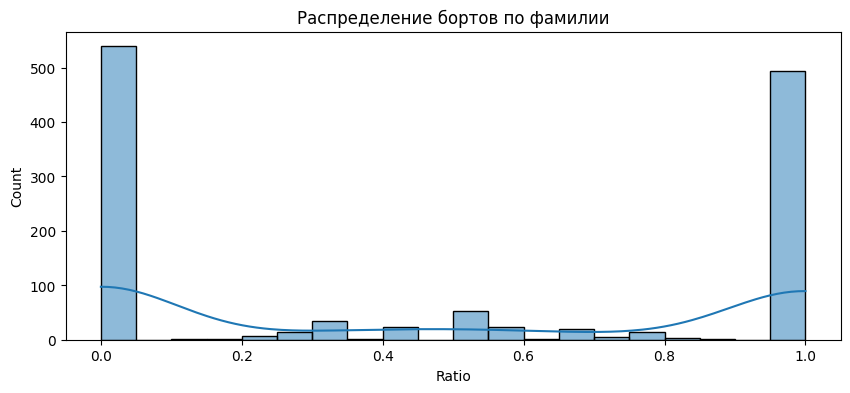

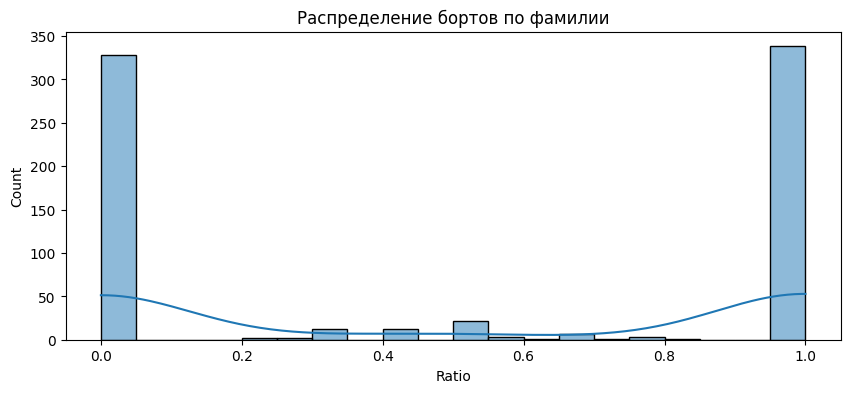

In [93]:
for data in data_cleaner:
    
    SCS_gb=data[data['Group_size']>1].groupby(['Surname','Cabin_side'])['Cabin_side'].size().unstack().fillna(0)

    SCS_gb['Ratio']=SCS_gb['P']/(SCS_gb['P']+SCS_gb['S'])

    # 0 - Все на S, 1 - Все на P
    plt.figure(figsize=(10,4))
    sns.histplot(SCS_gb['Ratio'], kde=True, binwidth=0.05)
    plt.title('Распределение бортов по фамилии')

In [94]:

print('Процент фамилий, которые находятся на одном борту:', 100*np.round((SCS_gb['Ratio'].isin([0,1])).sum()/len(SCS_gb),3),'%')

SCS_gb.head()

Процент фамилий, которые находятся на одном борту: 91.0 %


Cabin_side,P,S,Ratio
Surname,,,
Acobsond,3.0,0.0,1.0
Aginge,3.0,0.0,1.0
Aillyber,3.0,0.0,1.0
Aindlylid,0.0,1.0,0.0
Airdring,0.0,2.0,0.0


In [95]:
SCS_gb.drop('Ratio', axis=1, inplace=True)
    
for data in data_cleaner:

    CS_bef = data['Cabin_side'].isna().sum()
    
    # Логика все та же, но с фамилиями
    SCS_index=data[data['Cabin_side'].isna()][(data[data['Cabin_side'].isna()]['Surname']).isin(SCS_gb.index)].index

    data.loc[SCS_index,'Cabin_side']=data.iloc[SCS_index,:]['Surname'].map(lambda x: SCS_gb.idxmax(axis=1)[x])

    data.drop('Surname', axis=1, inplace=True)

    print('Пропущенных до:',CS_bef)
    print('Пропущенных после:',data['Cabin_side'].isna().sum())

Пропущенных до: 99
Пропущенных после: 74
Пропущенных до: 63
Пропущенных после: 45


In [96]:
for data in data_cleaner:
    
    data['Cabin_side'].value_counts()

    CS_bef=data['Cabin_side'].isna().sum()

    # Заполним Z
    data.loc[data['Cabin_side'].isna(),'Cabin_side']='Z'

    print('Пропущенных до:',CS_bef)
    print('Пропущенных после:',data['Cabin_side'].isna().sum())

Пропущенных до: 74
Пропущенных после: 0
Пропущенных до: 45
Пропущенных после: 0


In [97]:
for data in data_cleaner:
    
    CD_bef=data['Cabin_deck'].isna().sum()

    # Опять же палубу заполняем той, которая самая "популярная" в группе
    GCD_index=data[data['Cabin_deck'].isna()][(data[data['Cabin_deck'].isna()]['Group']).isin(GCD_gb.index)].index

    data.loc[GCD_index,'Cabin_deck']=data.iloc[GCD_index,:]['Group'].map(lambda x: GCD_gb.idxmax(axis=1)[x])

    print('Пропущенных до:',CD_bef)
    print('Пропущенных после:',data['Cabin_deck'].isna().sum())


Пропущенных до: 199
Пропущенных после: 199
Пропущенных до: 100
Пропущенных после: 63


In [98]:
dataset = data_cleaner[0]
dataset[["HomePlanet", "Cabin_deck"]].pivot_table(index='HomePlanet', columns="Cabin_deck", aggfunc='size')

Cabin_deck,A,B,C,D,E,F,G,T
HomePlanet,,,,,,,,
Earth,NaN,NaN,NaN,NaN,404.0,1652.0,2559.0,NaN
Europa,256.0,779.0,747.0,192.0,133.0,NaN,NaN,5.0
Mars,NaN,NaN,NaN,286.0,339.0,1142.0,NaN,NaN


In [ ]:
for data in data_cleaner:
    data.groupby(['HomePlanet','Destination','Solo','Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)
    '''
    Пассажиры с Марса обычно на палубе F.
    Пассажиры с Европы обычно на палубе C, если одни иначе на палубе B
    Пассажиры с Земли обычно на палубе G.
    Заполняем все модой
    '''
    CD_bef=data['Cabin_deck'].isna().sum()

    na_rows_CD=data.loc[data['Cabin_deck'].isna(),'Cabin_deck'].index
    data.loc[data['Cabin_deck'].isna(),'Cabin_deck']=data.groupby(['HomePlanet','Destination','Solo'])['Cabin_deck'].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CD]

    print('Пропущенных до:',CD_bef)
    print('Пропущенных после:',data['Cabin_deck'].isna().sum())

Пропущенных до: 199
Пропущенных после: 0
Пропущенных до: 63
Пропущенных после: 0


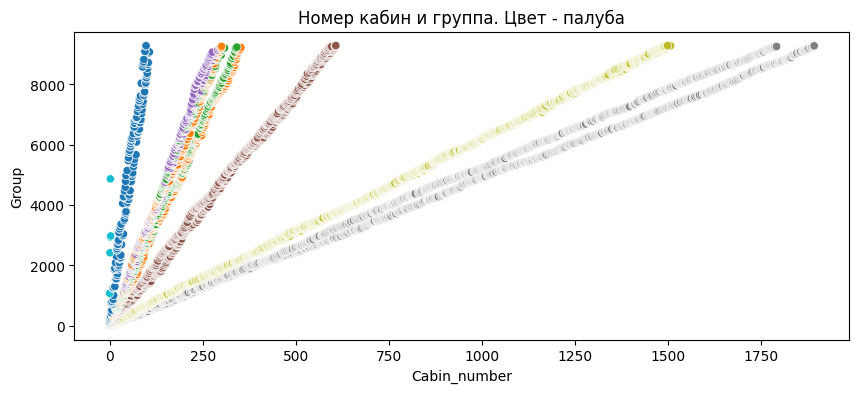

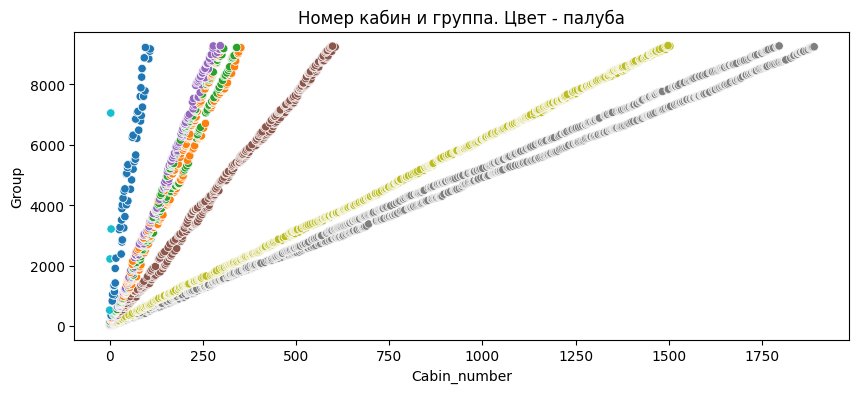

In [100]:
for data in data_cleaner:
    
    plt.figure(figsize=(10,4))
    sns.scatterplot(x=data['Cabin_number'], y=data['Group'], c=LabelEncoder().fit_transform(data.loc[~data['Cabin_number'].isna(),'Cabin_deck']), cmap='tab10')
    plt.title('Номер кабин и группа. Цвет - палуба')

In [101]:
for data in data_cleaner:
    
    CN_bef=data['Cabin_number'].isna().sum()
    
    for deck in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
        
        X_CN=data.loc[~(data['Cabin_number'].isna()) & (data['Cabin_deck']==deck),'Group']
        y_CN=data.loc[~(data['Cabin_number'].isna()) & (data['Cabin_deck']==deck),'Cabin_number']
        X_test_CN=data.loc[(data['Cabin_number'].isna()) & (data['Cabin_deck']==deck),'Group']
        
        if not X_test_CN.empty:

            model_CN=sklearn.linear_model.LinearRegression()
            model_CN.fit(X_CN.values.reshape(-1, 1), y_CN)
            preds_CN=model_CN.predict(X_test_CN.values.reshape(-1, 1))

            # Линейной регрессией заполняем недостающие номера кабин
            data.loc[(data['Cabin_number'].isna()) & (data['Cabin_deck']==deck),'Cabin_number']=preds_CN.astype(int)

    print('Пропущенных до:',CN_bef)
    print('Пропущенных после:',data['Cabin_number'].isna().sum())

    data['Cabin_region1']=(data['Cabin_number']<300).astype(int)
    data['Cabin_region2']=((data['Cabin_number']>=300) & (data['Cabin_number']<600)).astype(int)
    data['Cabin_region3']=((data['Cabin_number']>=600) & (data['Cabin_number']<900)).astype(int)
    data['Cabin_region4']=((data['Cabin_number']>=900) & (data['Cabin_number']<1200)).astype(int)
    data['Cabin_region5']=((data['Cabin_number']>=1200) & (data['Cabin_number']<1500)).astype(int)
    data['Cabin_region6']=((data['Cabin_number']>=1500) & (data['Cabin_number']<1800)).astype(int)
    data['Cabin_region7']=(data['Cabin_number']>=1800).astype(int)

Пропущенных до: 199
Пропущенных после: 0
Пропущенных до: 100
Пропущенных после: 0


In [102]:
data[data['Cabin_number'].isna()]["Cabin_deck"]

Series([], Name: Cabin_deck, dtype: object)

In [103]:
for data in data_cleaner:
    
    V_bef=data['VIP'].isna().sum()

    # Заполним модой
    data.loc[data['VIP'].isna(),'VIP']=False

    print('Пропущенных до:',V_bef)
    print('Пропущенных после:',data['VIP'].isna().sum())

Пропущенных до: 203
Пропущенных после: 0
Пропущенных до: 93
Пропущенных после: 0


In [104]:
for data in data_cleaner:
    
    data.groupby(['HomePlanet','No_spending','Solo','Cabin_deck'])['Age'].median().unstack().fillna(0)
   
    A_bef=data[exp_feats].isna().sum().sum()

    # Используем медиану по нескольким показателям
    na_rows_A=data.loc[data['Age'].isna(),'Age'].index
    data.loc[data['Age'].isna(),'Age']=data.groupby(['HomePlanet','No_spending','Solo','Cabin_deck'])['Age'].transform(lambda x: x.fillna(x.median()))[na_rows_A]

    print('Пропущенных до:',A_bef)
    print('Пропущенных после:',data['Age'].isna().sum())

Пропущенных до: 943
Пропущенных после: 0
Пропущенных до: 467
Пропущенных после: 0


In [105]:
for data in data_cleaner:
    # Обновляем возрастную группу
    data.loc[data['Age']<=12,'Age_group']='Age_0-12'
    data.loc[(data['Age']>12) & (data['Age']<18),'Age_group']='Age_13-17'
    data.loc[(data['Age']>=18) & (data['Age']<=25),'Age_group']='Age_18-25'
    data.loc[(data['Age']>25) & (data['Age']<=30),'Age_group']='Age_26-30'
    data.loc[(data['Age']>30) & (data['Age']<=50),'Age_group']='Age_31-50'
    data.loc[data['Age']>50,'Age_group']='Age_51+'

In [106]:
for data in data_cleaner:
    
    data.groupby(['No_spending','CryoSleep'])['CryoSleep'].size().unstack().fillna(0)
   
    CSL_bef=data['CryoSleep'].isna().sum()

    # Модой
    na_rows_CSL=data.loc[data['CryoSleep'].isna(),'CryoSleep'].index
    data.loc[data['CryoSleep'].isna(),'CryoSleep']=data.groupby(['No_spending'])['CryoSleep'].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CSL]

    print('Пропущенных до:',CSL_bef)
    print('Пропущенных после:',data['CryoSleep'].isna().sum())

Пропущенных до: 217
Пропущенных после: 0
Пропущенных до: 93
Пропущенных после: 0


C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\953007613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.loc[data['CryoSleep'].isna(),'CryoSleep']=data.groupby(['No_spending'])['CryoSleep'].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CSL]
C:\Users\Sherb\AppData\Local\Temp\ipykernel_5872\953007613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.loc[data['CryoSleep'].isna(),'CryoSleep']=data.groupby(['No_spending'])['CryoSleep'].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CSL]


In [107]:
dataset = data_cleaner[0][["CryoSleep", *exp_feats]]

# Если в криосне, то трат нет
dataset[dataset["CryoSleep"]].groupby(["CryoSleep"]).max()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
CryoSleep,,,,,
True,0.0,0.0,0.0,0.0,0.0


In [108]:
for data in data_cleaner:
    
    E_bef=data[exp_feats].isna().sum().sum()

    for col in exp_feats:
        data.loc[(data[col].isna()) & (data['CryoSleep']==True), col]=0

    print('Пропущенных до:',E_bef)
    print('Пропущенных после:',data[exp_feats].isna().sum().sum())

Пропущенных до: 943
Пропущенных после: 571
Пропущенных до: 467
Пропущенных после: 295


In [109]:
data_cleaner[0].columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported', 'Age_group', 'Expenditure', 'No_spending', 'Group',
       'Group_size', 'Solo', 'Cabin_deck', 'Cabin_number', 'Cabin_side',
       'Cabin_region1', 'Cabin_region2', 'Cabin_region3', 'Cabin_region4',
       'Cabin_region5', 'Cabin_region6', 'Cabin_region7', 'Family_size'],
      dtype='object')

In [110]:
for data in data_cleaner:
    
    data.groupby(['HomePlanet','Solo','Age_group'])['Expenditure'].mean().unstack().fillna(0)
    
    E_bef=data[exp_feats].isna().sum().sum()

    # Медианой
    for col in exp_feats:
        na_rows=data.loc[data[col].isna(),col].index
        data.loc[data[col].isna(),col]=data.groupby(['HomePlanet','Solo','Age_group'])[col].transform(lambda x: x.fillna(x.mean()))[na_rows]

    print('Пропущенных до:',E_bef)
    print('Пропущенных после:',data[exp_feats].isna().sum().sum())

Пропущенных до: 571
Пропущенных после: 0
Пропущенных до: 295
Пропущенных после: 0


In [111]:
for data in data_cleaner:
    
    data['Expenditure']=data[exp_feats].sum(axis=1)
    data['No_spending']=(data['Expenditure']==0).astype(int)
    data.isna().sum()
    # log преобразование
    for col in ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Expenditure']:
        data[col]=np.log(1+data[col])

In [112]:
# В данном случае закодируем колонки

label = LabelEncoder()

for data in data_cleaner:

    data['HomePlanet_Code'] = label.fit_transform(data['HomePlanet'])
    data['CryoSleep_Code'] = label.fit_transform(data['CryoSleep'])
    data['Destination_Code'] = label.fit_transform(data['Destination'])
    data['VIP_Code'] = label.fit_transform(data['VIP'])
    data['Age_group_Code'] = label.fit_transform(data['Age_group'])
    data['Cabin_deck_Code'] = label.fit_transform(data['Cabin_deck'])
    data['Cabin_side_Code'] = label.fit_transform(data['Cabin_side'])

In [113]:
Target = ['Transported']

# x параметры

# 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'
data1_x = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
# 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Age_group', 'Expenditure', 'No_spending', 'Group', 'Group_size', 'Solo', 'Cabin_deck', 'Cabin_number', 'Cabin_side', 'Cabin_region1', 'Cabin_region2', 'Cabin_region3', 'Cabin_region4', 'Cabin_region5', 'Cabin_region6', 'Cabin_region7', 'Family_size', 'HomePlanet_Code', 'CryoSleep_Code', 'Destination_Code', 'VIP_Code', 'Age_group_Code', 'Cabin_deck_Code', 'Cabin_side_Code'

data1_x_calc = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Expenditure', 'No_spending', 'Group', 'Group_size', 'Solo', 'Cabin_number', 'Cabin_region1', 'Cabin_region2', 'Cabin_region3', 'Cabin_region4', 'Cabin_region5', 'Cabin_region6', 'Cabin_region7', 'Family_size', 'HomePlanet_Code', 'CryoSleep_Code', 'Destination_Code', 'VIP_Code', 'Age_group_Code', 'Cabin_deck_Code', 'Cabin_side_Code'] # coded for algorithm calculation
data1_xy =  Target + data1_x
print('Изначальные X Y: ', data1_xy, '\n')


data1_x_bin = ['Age', 'No_spending', 'Group_size', 'Solo', 'Cabin_region1', 'Cabin_region2', 'Cabin_region3', 'Cabin_region4', 'Cabin_region5', 'Cabin_region6', 'Cabin_region7', 'Family_size', 'HomePlanet_Code', 'CryoSleep_Code', 'Destination_Code', 'VIP_Code', 'Age_group_Code', 'Cabin_deck_Code', 'Cabin_side_Code']
data1_xy_bin = Target + data1_x_bin
print('Bin X Y: ', data1_xy_bin, '\n')


data1_dummy = pd.get_dummies(data_train_copy[data1_x])
data1_x_dummy = data1_dummy.columns.tolist()
data1_xy_dummy = Target + data1_x_dummy
print('Dummy X Y: ', data1_xy_dummy, '\n')



data1_dummy.head()

Изначальные X Y:  ['Transported', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'] 

Bin X Y:  ['Transported', 'Age', 'No_spending', 'Group_size', 'Solo', 'Cabin_region1', 'Cabin_region2', 'Cabin_region3', 'Cabin_region4', 'Cabin_region5', 'Cabin_region6', 'Cabin_region7', 'Family_size', 'HomePlanet_Code', 'CryoSleep_Code', 'Destination_Code', 'VIP_Code', 'Age_group_Code', 'Cabin_deck_Code', 'Cabin_side_Code'] 

Dummy X Y:  ['Transported', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'CryoSleep_False', 'CryoSleep_True', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP_False', 'VIP_True'] 



,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_False,CryoSleep_True,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_False,VIP_True
0,39.0,0.000000,0.000000,0.000000,0.000000,0.000000,False,True,False,True,False,False,False,True,True,False
1,24.0,4.700480,2.302585,3.258097,6.309918,3.806662,True,False,False,True,False,False,False,True,True,False
2,58.0,3.784190,8.182280,0.000000,8.812248,3.912023,False,True,False,True,False,False,False,True,False,True
3,33.0,0.000000,7.157735,5.918894,8.110728,5.267858,False,True,False,True,False,False,False,True,True,False
4,16.0,5.717028,4.262680,5.023881,6.338594,1.098612,True,False,False,True,False,False,False,True,True,False


In [114]:
print('Тренировочные: \n', data_train_copy.isnull().sum())
print("-"*10)
print (data_train_copy.info())
print("-"*10)

print('Тестовые: \n', data_test.isnull().sum())
print("-"*10)
print (data_test.info())
print("-"*10)

data_train.describe(include = 'all')

Тренировочные: 
 PassengerId         0
HomePlanet          0
CryoSleep           0
Destination         0
Age                 0
VIP                 0
RoomService         0
FoodCourt           0
ShoppingMall        0
Spa                 0
VRDeck              0
Transported         0
Age_group           0
Expenditure         0
No_spending         0
Group               0
Group_size          0
Solo                0
Cabin_deck          0
Cabin_number        0
Cabin_side          0
Cabin_region1       0
Cabin_region2       0
Cabin_region3       0
Cabin_region4       0
Cabin_region5       0
Cabin_region6       0
Cabin_region7       0
Family_size         0
HomePlanet_Code     0
CryoSleep_Code      0
Destination_Code    0
VIP_Code            0
Age_group_Code      0
Cabin_deck_Code     0
Cabin_side_Code     0
dtype: int64
----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------  

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693,8492,8476,8494,8511,8514.000000,8490,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000,8493,8693
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2
top,9280_02,Earth,False,G/734/S,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,NaN,NaN,Anton Woody,True
freq,1,4602,5439,8,5915,NaN,8291,NaN,NaN,NaN,NaN,NaN,2,4378
mean,NaN,NaN,NaN,NaN,NaN,28.827930,NaN,224.687617,458.077203,173.729169,311.138778,304.854791,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.489021,NaN,666.717663,1611.489240,604.696458,1136.705535,1145.717189,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,47.000000,76.000000,27.000000,59.000000,46.000000,NaN,NaN


In [115]:

train1_x, test1_x, train1_y, test1_y = model_selection.train_test_split(data_train_copy[data1_x_calc], data_train_copy[Target], random_state = 0)
train1_x_bin, test1_x_bin, train1_y_bin, test1_y_bin = model_selection.train_test_split(data_train_copy[data1_x_bin], data_train_copy[Target] , random_state = 0)
train1_x_dummy, test1_x_dummy, train1_y_dummy, test1_y_dummy = model_selection.train_test_split(data1_dummy[data1_x_dummy], data_train_copy[Target], random_state = 0)


print("Data1 размер: {}".format(data_train_copy.shape))
print("Train1 размер: {}".format(train1_x.shape))
print("Test1 размер: {}".format(test1_x.shape))

train1_x_bin.head()

Data1 размер: (8693, 36)
Train1 размер: (6519, 27)
Test1 размер: (2174, 27)


,Age,No_spending,Group_size,Solo,Cabin_region1,Cabin_region2,Cabin_region3,Cabin_region4,Cabin_region5,Cabin_region6,Cabin_region7,Family_size,HomePlanet_Code,CryoSleep_Code,Destination_Code,VIP_Code,Age_group_Code,Cabin_deck_Code,Cabin_side_Code
5020,37.0,1,1,1,0,0,0,1,0,0,0,4,2,1,2,0,4,5,0
5967,44.0,1,3,0,0,0,0,1,0,0,0,7,0,1,0,0,4,6,1
991,27.0,0,1,1,1,0,0,0,0,0,0,2,0,0,1,0,3,5,1
2894,15.0,0,1,1,0,1,0,0,0,0,0,6,0,0,0,0,1,6,0
2228,23.0,0,1,1,0,1,0,0,0,0,0,3,2,0,2,0,2,5,1


In [116]:
for x in data1_x:
    if data_train_copy[x].dtype != 'float64' :
        print('Transported Correlation by:', x)
        print(data_train_copy[[x, Target[0]]].groupby(x, as_index=False).mean())
        print('-'*10, '\n')  

Transported Correlation by: HomePlanet
  HomePlanet  Transported
0      Earth     0.423420
1     Europa     0.660534
2       Mars     0.524100
---------- 

Transported Correlation by: CryoSleep
  CryoSleep  Transported
0     False     0.328176
1      True     0.814673
---------- 

Transported Correlation by: Destination
     Destination  Transported
0    55 Cancri e     0.610000
1  PSO J318.5-22     0.503769
2    TRAPPIST-1e     0.472199
---------- 

Transported Correlation by: VIP
     VIP  Transported
0  False     0.506475
1   True     0.381910
---------- 



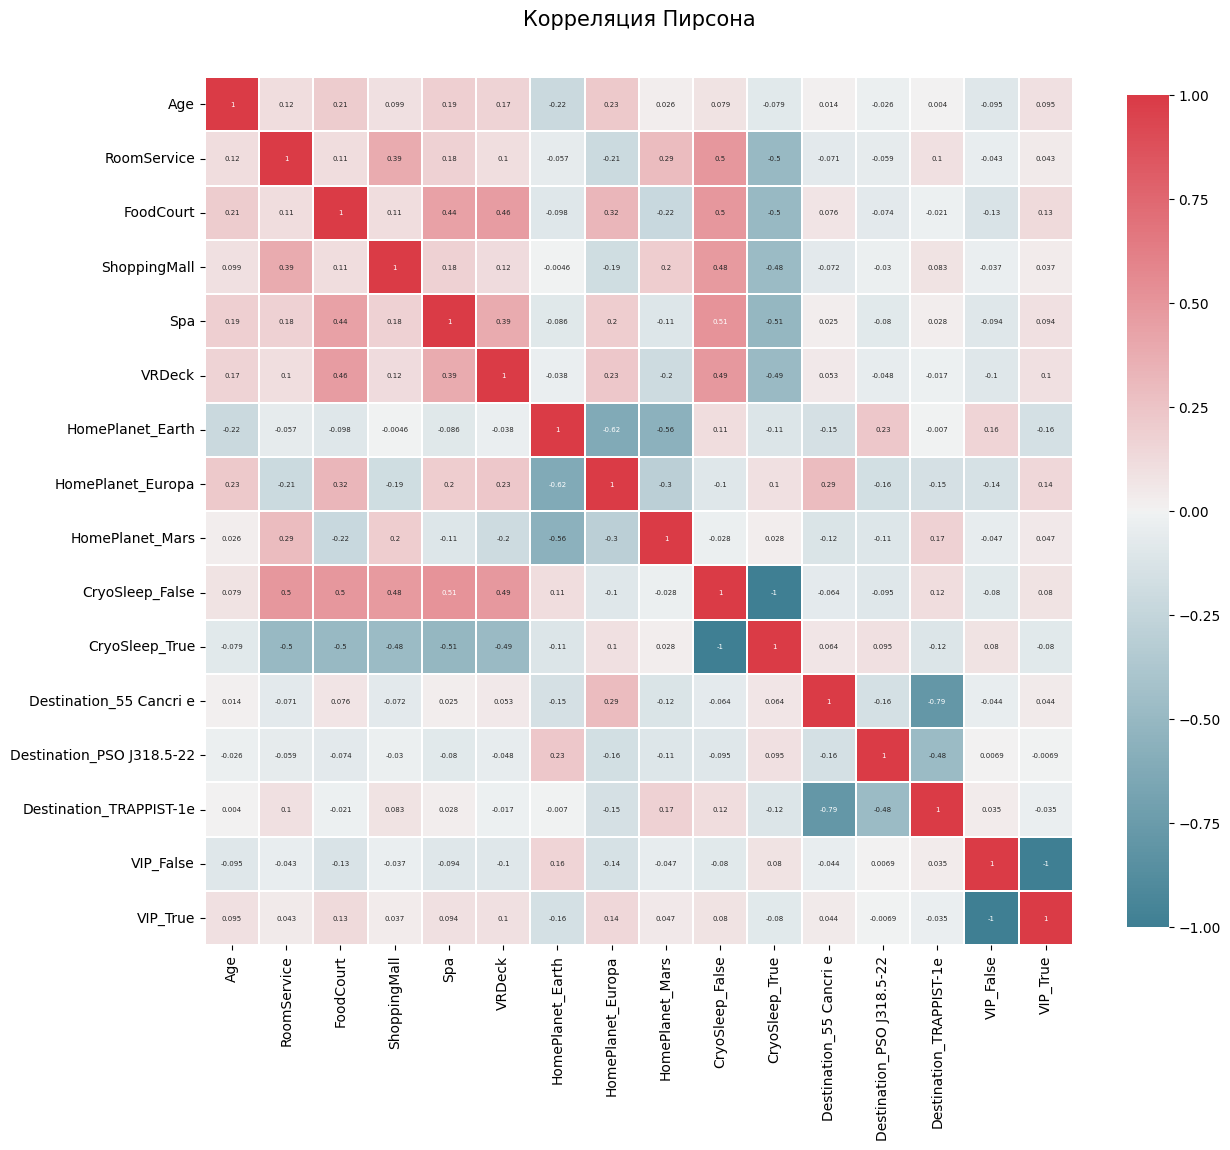

In [117]:
def correlation_heatmap(df):
    _ , ax = plt.subplots(figsize =(14, 12))
    colormap = sns.diverging_palette(220, 10, as_cmap = True)
    
    _ = sns.heatmap(
        df.corr(), 
        cmap = colormap,
        square=True, 
        cbar_kws={'shrink':.9 }, 
        ax=ax,
        annot=True, 
        linewidths=0.1,vmax=1.0, linecolor='white',
        annot_kws={'fontsize': 5 }
    )
    
    plt.title('Корреляция Пирсона', y=1.05, size=15)

correlation_heatmap(train1_x_dummy)

In [121]:
cv_split = model_selection.ShuffleSplit(n_splits = 10, test_size = .3, train_size = .6, random_state = 0 )

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

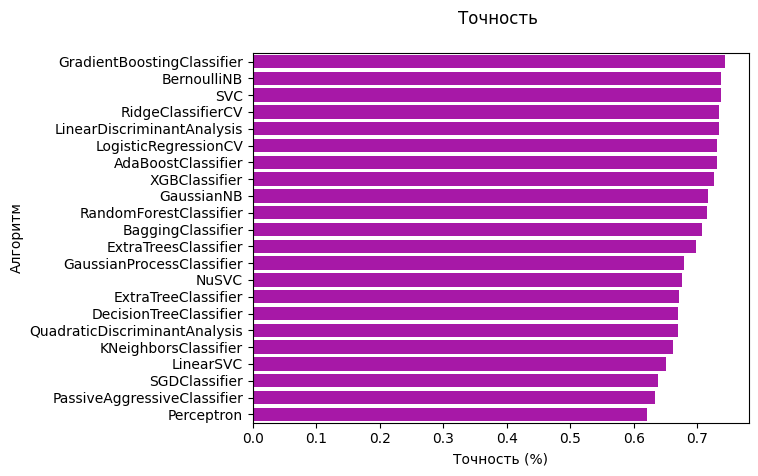

In [ ]:

if False:
    MLA = [
        
        ensemble.AdaBoostClassifier(),
        ensemble.BaggingClassifier(),
        ensemble.ExtraTreesClassifier(),
        ensemble.GradientBoostingClassifier(),
        ensemble.RandomForestClassifier(),
    
        
        gaussian_process.GaussianProcessClassifier(),
        
       
        linear_model.LogisticRegressionCV(),
        linear_model.PassiveAggressiveClassifier(),
        linear_model.RidgeClassifierCV(),
        linear_model.SGDClassifier(),
        linear_model.Perceptron(),
        
        
        naive_bayes.BernoulliNB(),
        naive_bayes.GaussianNB(),
        
        
        neighbors.KNeighborsClassifier(),
        
        
        svm.SVC(probability=True),
        svm.NuSVC(probability=True),
        svm.LinearSVC(),
        
           
        tree.DecisionTreeClassifier(),
        tree.ExtraTreeClassifier(),
        
        
        discriminant_analysis.LinearDiscriminantAnalysis(),
        discriminant_analysis.QuadraticDiscriminantAnalysis(),
    
        
        
        XGBClassifier()    
        ]
    
    MLA_columns = ['MLA Name', 'MLA Parameters','MLA Train Accuracy Mean', 'MLA Test Accuracy Mean', 'MLA Test Accuracy 3*STD' ,'MLA Time']
    MLA_compare = pd.DataFrame(columns = MLA_columns)
    
    MLA_predict = data_train_copy[Target]
    
    row_index = 0
    for alg in MLA:
    
        #set name and parameters
        MLA_name = alg.__class__.__name__
        MLA_compare.loc[row_index, 'MLA Name'] = MLA_name
        MLA_compare.loc[row_index, 'MLA Parameters'] = str(alg.get_params())
        
        cv_results = model_selection.cross_validate(alg, data_train_copy[data1_x_bin], data_train_copy[Target], cv  = cv_split, return_train_score=True )
    
        MLA_compare.loc[row_index, 'MLA Time'] = cv_results['fit_time'].mean()
        MLA_compare.loc[row_index, 'MLA Train Accuracy Mean'] = cv_results['train_score'].mean()
        MLA_compare.loc[row_index, 'MLA Test Accuracy Mean'] = cv_results['test_score'].mean()   
        
        MLA_compare.loc[row_index, 'MLA Test Accuracy 3*STD'] = cv_results['test_score'].std()*3   
        
        alg.fit(data_train_copy[data1_x_bin], data_train_copy[Target])
        MLA_predict[MLA_name] = alg.predict(data_train_copy[data1_x_bin])
        
        row_index+=1
        
    
    MLA_compare.sort_values(by = ['MLA Test Accuracy Mean'], ascending = False, inplace = True)
    sns.barplot(x='MLA Test Accuracy Mean', y = 'MLA Name', data = MLA_compare, color = 'm')
    plt.title('Точность \n')
    plt.xlabel('Точность (%)')
    plt.ylabel('Алгоритм')
    MLA_compare.to_csv("/kaggle/working/models_accuracy.csv")


In [119]:
pivot_age = data_train_copy.groupby(['Age_group'])['Transported'].mean()
print('Перемещение в другое измерение в зависимости от группы: \n',pivot_age)

pivot_vip = data_train_copy.groupby(['VIP_Code'])['Transported'].mean()
print('\n Перемещение в другое измерение в зависимости от VIP: \n',pivot_vip)

pivot_HomePlanet = data_train_copy.groupby(['HomePlanet_Code'])['Transported'].mean()
print('\n Перемещение в другое измерение в зависимости от родной планеты: \n',pivot_HomePlanet)

pivot_CryoSleep = data_train_copy.groupby(['CryoSleep_Code'])['Transported'].mean()
print('\n Перемещение в другое измерение в зависимости от криосна: \n',pivot_CryoSleep)

pivot_Cabin_deck_Code = data_train_copy.groupby(['Cabin_deck_Code'])['Transported'].mean()
print('\n Перемещение в другое измерение в зависимости от палубы: \n',pivot_Cabin_deck_Code)

pivot_Cabin_side_Code = data_train_copy.groupby(['Cabin_side_Code'])['Transported'].mean()
print('\n Перемещение в другое измерение в зависимости от борта: \n',pivot_Cabin_side_Code)

Перемещение в другое измерение в зависимости от группы: 
 Age_group
Age_0-12     0.696126
Age_13-17    0.553451
Age_18-25    0.459674
Age_26-30    0.497276
Age_31-50    0.478437
Age_51+      0.484396
Name: Transported, dtype: float64

 Перемещение в другое измерение в зависимости от VIP: 
 VIP_Code
0    0.506475
1    0.381910
Name: Transported, dtype: float64

 Перемещение в другое измерение в зависимости от родной планеты: 
 HomePlanet_Code
0    0.423420
1    0.660534
2    0.524100
Name: Transported, dtype: float64

 Перемещение в другое измерение в зависимости от криосна: 
 CryoSleep_Code
0    0.328176
1    0.814673
Name: Transported, dtype: float64

 Перемещение в другое измерение в зависимости от палубы: 
 Cabin_deck_Code
0    0.496094
1    0.732601
2    0.677503
3    0.433054
4    0.357306
5    0.440141
6    0.512830
7    0.200000
Name: Transported, dtype: float64

 Перемещение в другое измерение в зависимости от борта: 
 Cabin_side_Code
0    0.452498
1    0.555326
2    0.405405
N

In [122]:
dtree = tree.DecisionTreeClassifier(random_state = 0)
base_results = model_selection.cross_validate(dtree, data_train_copy[data1_x_bin], data_train_copy[Target], cv  = cv_split, return_train_score=True )
dtree.fit(data_train_copy[data1_x_bin], data_train_copy[Target])

print('Перед выбором параметров: ', dtree.get_params())
print("Перед выбором параметров train_score: {:.2f}". format(base_results['train_score'].mean()*100)) 
print("Перед выбором параметров test_score: {:.2f}". format(base_results['test_score'].mean()*100))
print("Перед выбором параметров test_score 3*std: +/- {:.2f}". format(base_results['test_score'].std()*100*3))
print('-'*10)


param_grid = {'criterion': ['gini', 'entropy'],
              'max_depth': [2,4,6,8,10,None],
              'random_state': [0]
             }

tune_model = model_selection.GridSearchCV(tree.DecisionTreeClassifier(), param_grid=param_grid, scoring = 'roc_auc', cv = cv_split, return_train_score=True )
tune_model.fit(data_train_copy[data1_x_bin], data_train_copy[Target])

print('После выборов параметров: ', tune_model.best_params_)
print("После выборов параметров train_score: {:.2f}". format(tune_model.cv_results_['mean_train_score'][tune_model.best_index_]*100)) 
print("После выборов параметров test_score: {:.2f}". format(tune_model.cv_results_['mean_test_score'][tune_model.best_index_]*100))
print("После выборов параметров test_score 3*std: +/- {:.2f}". format(tune_model.cv_results_['std_test_score'][tune_model.best_index_]*100*3))
print('-'*10)

Перед выбором параметров:  {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}
Перед выбором параметров train_score: 99.09
Перед выбором параметров test_score: 66.87
Перед выбором параметров test_score 3*std: +/- 3.11
----------
После выборов параметров:  {'criterion': 'gini', 'max_depth': 6, 'random_state': 0}
После выборов параметров train_score: 83.49
После выборов параметров test_score: 80.15
После выборов параметров test_score 3*std: +/- 1.57
----------


In [123]:
dtree_rfe = feature_selection.RFECV(dtree, step = 1, scoring = 'accuracy', cv = cv_split)
dtree_rfe.fit(data_train_copy[data1_x_bin], data_train_copy[Target])

X_rfe = data_train_copy[data1_x_bin].columns.values[dtree_rfe.get_support()]
rfe_results = model_selection.cross_validate(dtree, data_train_copy[X_rfe], data_train_copy[Target], cv  = cv_split, return_train_score=True )

rfe_tune_model = model_selection.GridSearchCV(tree.DecisionTreeClassifier(), param_grid=param_grid, scoring = 'roc_auc', cv = cv_split, return_train_score=True )
rfe_tune_model.fit(data_train_copy[X_rfe], data_train_copy[Target])

GridSearchCV(cv=ShuffleSplit(n_splits=10, random_state=0, test_size=0.3, train_size=0.6),
             estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, None],
                         'random_state': [0]},
             return_train_score=True, scoring='roc_auc')

In [92]:
data1_dummy

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_False,CryoSleep_True,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_False,VIP_True
0,39.0,0.000000,0.000000,0.000000,0.000000,0.000000,False,True,False,True,False,False,False,True,True,False
1,24.0,4.700480,2.302585,3.258097,6.309918,3.806662,True,False,False,True,False,False,False,True,True,False
2,58.0,3.784190,8.182280,0.000000,8.812248,3.912023,False,True,False,True,False,False,False,True,False,True
3,33.0,0.000000,7.157735,5.918894,8.110728,5.267858,False,True,False,True,False,False,False,True,True,False
4,16.0,5.717028,4.262680,5.023881,6.338594,1.098612,True,False,False,True,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,41.0,0.000000,8.827615,0.000000,7.404888,4.317488,False,True,False,True,False,True,False,False,False,True
8689,18.0,0.000000,0.000000,0.000000,0.000000,0.000000,True,False,False,False,True,False,True,False,True,False
8690,26.0,0.000000,0.000000,7.535297,0.693147,0.000000,True,False,False,True,False,False,False,True,True,False
8691,32.0,0.000000,6.956545,0.000000,5.869297,8.082093,False,True,False,True,False,True,False,False,True,False


In [ ]:


class GBParameterOptimizer:
    def __init__(self, X, y, n_iter=100, cv=5, scoring='roc_auc', n_jobs=-1):
        """
        Инициализация оптимизатора параметров
        
        Параметры:
        X, y - данные и целевая переменная
        n_iter - количество итераций для RandomizedSearchCV
        cv - количество фолдов для кросс-валидации
        scoring - метрика для оптимизации
        n_jobs - количество ядер для параллельных вычислений
        """
        self.X = X
        self.y = y
        self.n_iter = n_iter
        self.cv = cv
        self.scoring = scoring
        self.n_jobs = n_jobs
        self.best_params_ = None
        self.best_score_ = None
        self.best_estimator_ = None
        self.search_results_ = None
        
    def _create_param_distributions(self):
        """Создание пространства параметров для поиска"""
        return {
            'n_estimators': randint(50, 500),
            'learning_rate': uniform(0.01, 0.3),
            'max_depth': randint(3, 10),
            'min_samples_split': randint(2, 20),
            'min_samples_leaf': randint(1, 10),
            'max_features': ['sqrt', 'log2', None],
            'subsample': uniform(0.6, 0.4),
            'loss': ['log_loss', 'exponential'],
            'criterion': ['friedman_mse', 'squared_error']
        }
    
    def optimize(self):
        """Основной метод оптимизации параметров"""
        gbc = GradientBoostingClassifier(random_state=42, warm_start=True)
        
        param_dist = self._create_param_distributions()
        
        # Используем контекстный менеджер для управления параллельными вычислениями
        with parallel_backend('threading', n_jobs=self.n_jobs):
            search = RandomizedSearchCV(
                estimator=gbc,
                param_distributions=param_dist,
                n_iter=self.n_iter,
                cv=self.cv,
                scoring=self.scoring,
                n_jobs=self.n_jobs,
                verbose=2,
                random_state=42,
                return_train_score=True
            )
            
            start_time = time.time()
            search.fit(self.X, self.y)
            elapsed_time = time.time() - start_time
            
            print(f"Оптимизация завершена за {elapsed_time:.2f} секунд")
            
            self.best_params_ = search.best_params_
            self.best_score_ = search.best_score_
            self.best_estimator_ = search.best_estimator_
            self.search_results_ = pd.DataFrame(search.cv_results_)
            
        return self
    
    def evaluate(self, X_test, y_test):
        """Оценка лучшей модели на тестовых данных"""
        if self.best_estimator_ is None:
            raise ValueError("Сначала выполните метод optimize()")
            
        y_pred = self.best_estimator_.predict(X_test)
        y_proba = self.best_estimator_.predict_proba(X_test)[:, 1]
        
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_proba),
            'f1_score': f1_score(y_test, y_pred)
        }
        
        return metrics
    
    def get_feature_importances(self):
        """Получение важности признаков из лучшей модели"""
        if self.best_estimator_ is None:
            raise ValueError("Сначала выполните метод optimize()")
            
        return pd.DataFrame({
            'feature': range(self.X.shape[1]),
            'importance': self.best_estimator_.feature_importances_
        }).sort_values('importance', ascending=False)

In [126]:
Transported = data_train_copy["Transported"]

In [117]:
if False:

    X_train, X_test, y_train, y_test = train_test_split(data1_dummy, Transported, test_size=0.2, random_state=42)
        
    # Инициализируем и запускаем оптимизатор
    optimizer = GBParameterOptimizer(
        X_train, 
        y_train, 
        n_iter=100, 
        cv=5, 
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # Оптимизируем параметры
    optimizer.optimize()
    
    # Выводим результаты
    print("\nЛучшие параметры:")
    print(optimizer.best_params_)
    print(f"\nЛучший score (кросс-валидация): {optimizer.best_score_:.4f}")
    
    # Оцениваем на тестовых данных
    test_metrics = optimizer.evaluate(X_test, y_test)
    print("\nМетрики на тестовых данных:")
    for metric, value in test_metrics.items():
        print(f"{metric}: {value:.4f}")
    
    # Важность признаков
    print("\nТоп-10 важных признаков:")
    print(optimizer.get_feature_importances().head(10))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END criterion=friedman_mse, learning_rate=0.24896289605806984, loss=log_loss, max_depth=5, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=171, subsample=0.662397808134481; total time=   4.0s
[CV] END criterion=friedman_mse, learning_rate=0.24896289605806984, loss=log_loss, max_depth=5, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=171, subsample=0.662397808134481; total time=   4.1s
[CV] END criterion=friedman_mse, learning_rate=0.24896289605806984, loss=log_loss, max_depth=5, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=171, subsample=0.662397808134481; total time=   4.2s
[CV] END criterion=friedman_mse, learning_rate=0.24896289605806984, loss=log_loss, max_depth=5, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=171, subsample=0.662397808134481; total time=   4.3s
[CV] END criterion=friedman_mse, learning_rate=0.

In [128]:
# Лучшие параметры на 10 итерациях
{'criterion': 'squared_error', 'learning_rate': 0.010233629752304298, 'loss': 'exponential', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 13, 'n_estimators': 394, 'subsample': 0.7164916560792167}
# на 100
best_params = {'criterion': 'squared_error', 'learning_rate': 0.010233629752304298, 'loss': 'exponential', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 13, 'n_estimators': 394, 'subsample': 0.7164916560792167}

In [129]:
dummy_columns = ['HomePlanet', 'Destination']

train_data = pd.get_dummies(data_train_copy, columns=dummy_columns)
test_data = pd.get_dummies(data_cleaner[1], columns=dummy_columns)

In [130]:
Y_train = train_data["Transported"]

In [131]:
X_train = train_data.drop(['Transported', 'Random_Predict', 'Random_Score'], axis=1)

In [132]:
X_test = test_data

In [133]:
X_train.drop(["Age_group"], axis=1, inplace=True)
X_test.drop(["Age_group"], axis=1, inplace=True)

In [134]:
X_train.drop(["Cabin_deck", "Cabin_side"], axis=1, inplace=True) 
X_test.drop(["Cabin_deck", "Cabin_side"], axis=1, inplace=True)

In [135]:
model = GradientBoostingClassifier(**best_params)
model.fit(X_train, Y_train)

GradientBoostingClassifier(criterion='squared_error',
                           learning_rate=0.010233629752304298,
                           loss='exponential', max_depth=7, max_features='sqrt',
                           min_samples_leaf=6, min_samples_split=13,
                           n_estimators=394, subsample=0.7164916560792167)

In [136]:
predictions = model.predict(X_test)

In [139]:
Result = pd.DataFrame({"PassengerId": X_test["PassengerId"], "Transported": predictions.astype(np.int64)}) 

In [140]:
Result.to_csv("sub.csv", index=False)